# AI-Based Resume Screening and Candidate Matching with Machine Learning and Deep Learning

**Final-year project, SRM Institute of Science and Technology**

This notebook walks through the full pipeline behind the JobMatch AI app:

1. Load and explore 2,483 real resumes in 24 job categories
2. Clean the text (remove personal data, emphasise the resume headline)
3. Train and compare machine-learning models (TF-IDF + Logistic Regression, Linear SVM, Naive Bayes, Random Forest)
4. Train a deep-learning model (word embeddings + 1D convolutional network)
5. Combine both into an ensemble and evaluate on unseen resumes
6. Use the models to match resumes to jobs

The full experiment with all models and repeated seeds is `train.py`; this notebook is the readable version.

**Running in Google Colab?** Run the next cell first. It downloads the project and installs the libraries.
On your own laptop, open this notebook from the project folder and skip it.

In [1]:
import os, sys
if "google.colab" in sys.modules and not os.path.exists("jobmatch"):
    !git clone -b claude/job-portal-ai-resume-screening-atzfzi https://github.com/SamrudhiDubal/Samrudhi-Dubal.git project
    %cd project
    !pip install -q -r requirements.txt
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # run from the project root so `jobmatch` and data/ are found
print("Working directory:", os.getcwd())

Working directory: /home/user/Samrudhi-Dubal


## 1. Load the dataset

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv("data/resumes.csv")
print("Rows:", len(df), "| columns:", list(df.columns))
print("Duplicate resumes:", df.duplicated("Resume_str").sum())
df = df.drop_duplicates("Resume_str").reset_index(drop=True)
df.head()

Rows: 2483 | columns: ['Resume_str', 'Category']
Duplicate resumes: 2


,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE HR ADMINI...,HR
1,"HR SPECIALIST, US HR OPERATIONS Summary Versat...",HR
2,HR DIRECTOR Summary Over 20 years experience i...,HR
3,"HR SPECIALIST Summary Dedicated, Driven, and D...",HR
4,HR MANAGER Skill Highlights HR SKILLS HR Depar...,HR


The dataset is the public **LiveCareer resume dataset** (CC0 licence): resumes as plain text with the job
category they were filed under. Email addresses, links and phone numbers were already removed by the
dataset's publisher, and our cleaning step removes any that remain.

> **Why not the popular 962-resume Kaggle dataset?** Only 166 of its 962 rows are unique. Random
> train/test splits put copies of the same resume on both sides, which is why many online projects report
> 99% accuracy. We checked this and chose a dataset without that leakage.

## 2. Exploratory data analysis

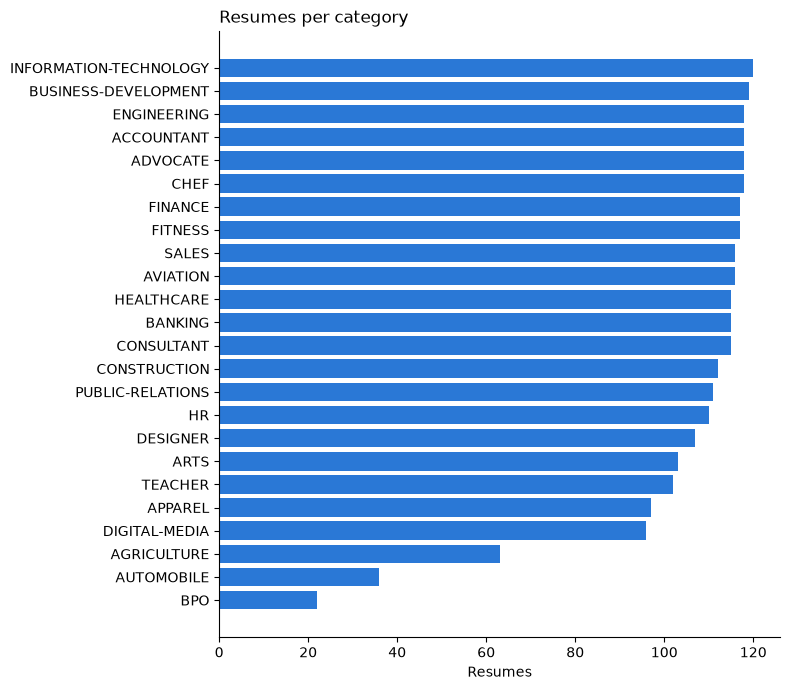

24 categories; smallest: BPO (22), largest: INFORMATION-TECHNOLOGY (120)


In [3]:
counts = df.Category.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(counts.index, counts.values, color="#2a78d6")
ax.set_title("Resumes per category", loc="left"); ax.set_xlabel("Resumes")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print(f"{df.Category.nunique()} categories; smallest: {counts.index[0]} ({counts.iloc[0]}), largest: {counts.index[-1]} ({counts.iloc[-1]})")

In [4]:
words = df.Resume_str.str.split().str.len()
print(words.describe().round(0))
print("\nFirst words of a few resumes (the resume headline):")
for t in df.Resume_str.sample(5, random_state=1):
    print("  ", " ".join(t.split()[:8]))

count    2481.0
mean      812.0
std       371.0
min       113.0
25%       651.0
50%       757.0
75%       934.0
max      5190.0
Name: Resume_str, dtype: float64

First words of a few resumes (the resume headline):
   SENIOR CONSTRUCTION MANAGER Summary Construction Manager / On
   SALES ASSOCIATE Experience 08/2014 to Current Sales Associate
   DIRECTOR OF DIGITAL TRANSFORMATION Executive Profile Digital and
   OFFICE MANAGER - 40+ HOURS PER WEEK Professional
   FINANCE SPECIALIST Summary Strategic Finance & Accounting Professional


Most categories have 100–120 resumes, but **BPO (22)** and **Automobile (36)** are small, so we expect
weaker results there. Resumes start with a headline (the person's job title), which is a strong clue.

## 3. Text preprocessing

In [5]:
from jobmatch.text import clean_text, prepare

sample = df.Resume_str.iloc[0]
print("RAW:     ", sample[:200])
print("CLEANED: ", clean_text(sample)[:200])
print("PREPARED:", prepare(sample)[:200])
df["text"] = df.Resume_str.map(prepare)

RAW:      HR ADMINISTRATOR/MARKETING ASSOCIATE HR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management. Respected builder and lead
CLEANED:  hr administrator marketing associate hr administrator summary dedicated customer service manager with 15+ years of experience in hospitality and customer service management respected builder and leade
PREPARED: hr administrator marketing associate hr administrator summary dedicated hr administrator marketing associate hr administrator summary dedicated hr administrator marketing associate hr administrator su


`prepare` lowercases the text, strips personal data and symbols, then **repeats the first 8 words three
times**. Repeating the headline gives the job title more weight. It is a simple feature-engineering step
that raised Linear SVM accuracy from about 68% to 74% in our experiments.

## 4. Train / test split

20% of resumes are held out as a **test set** and only used at the end. Models are compared with
**5-fold cross-validation** on the remaining 80%, and deep models use a 15% **validation** slice of the
training data for early stopping.

In [6]:
from sklearn.model_selection import train_test_split
labels = sorted(df.Category.unique())
y = df.Category.map({l: i for i, l in enumerate(labels)}).to_numpy()
idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, stratify=y, random_state=42)
idx_fit, idx_val = train_test_split(idx_train, test_size=0.15, stratify=y[idx_train], random_state=42)
X = df.text.to_numpy()
print(f"train {len(idx_train)} (fit {len(idx_fit)} + validation {len(idx_val)}), test {len(idx_test)}")

train 1984 (fit 1686 + validation 298), test 497


## 5. Machine learning models

Text becomes numbers with **TF-IDF** (term frequency × inverse document frequency) over single words and
word pairs. Four classifiers are compared with 5-fold cross-validation.

In [7]:
import time
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

def tfidf():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True,
                           stop_words="english", max_features=50000)

models = {
    "Logistic Regression": LogisticRegression(C=10, max_iter=3000),
    "Linear SVM": LinearSVC(C=0.5),
    "Naive Bayes": ComplementNB(alpha=0.3),
    "Random Forest": RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42),
}
cv = StratifiedKFold(5, shuffle=True, random_state=42)
cv_results = {}
for name, clf in models.items():
    t = time.time()
    scores = cross_val_score(Pipeline([("tfidf", tfidf()), ("clf", clf)]), X[idx_train], y[idx_train], cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:20s} CV accuracy {scores.mean():.3f} ± {scores.std():.3f}   ({time.time() - t:.0f}s)")

Logistic Regression  CV accuracy 0.701 ± 0.021   (72s)


Linear SVM           CV accuracy 0.716 ± 0.019   (16s)


Naive Bayes          CV accuracy 0.612 ± 0.024   (13s)


Random Forest        CV accuracy 0.714 ± 0.018   (31s)


**Linear SVM** is the strongest and fastest ML model, which is typical for high-dimensional sparse text.
We wrap it in `CalibratedClassifierCV` so it outputs probabilities, which matching needs.

In [8]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score

def report(name, y_true, proba):
    pred = proba.argmax(1)
    print(f"{name:28s} accuracy {accuracy_score(y_true, pred):.3f} | macro-F1 {f1_score(y_true, pred, average='macro'):.3f}"
          f" | top-3 {top_k_accuracy_score(y_true, proba, k=3, labels=range(len(labels))):.3f}")

svm = Pipeline([("tfidf", tfidf()), ("clf", CalibratedClassifierCV(LinearSVC(C=0.5), cv=3))])
svm_val = Pipeline([("tfidf", tfidf()), ("clf", CalibratedClassifierCV(LinearSVC(C=0.5), cv=3))]).fit(X[idx_fit], y[idx_fit])
svm.fit(X[idx_train], y[idx_train])
p_svm_val, p_svm_test = svm_val.predict_proba(X[idx_val]), svm.predict_proba(X[idx_test])
report("Linear SVM (test)", y[idx_test], p_svm_test)

Linear SVM (test)            accuracy 0.757 | macro-F1 0.710 | top-3 0.944


## 6. Deep learning model: 1D convolutional neural network

Each resume becomes a sequence of up to 600 word IDs. The network learns:

- an **embedding layer**: a 128-number vector for each of the 20,000 most common words
- a **1D convolution** with 128 filters of width 5, which detects useful 5-word phrases anywhere in the resume
- **global max pooling**, which keeps the strongest signal of each filter
- **dropout** (50%) against overfitting, a 64-unit dense layer (later reused as the "resume vector"), and a softmax over the 24 categories

Training stops early when validation loss stops improving.

In [9]:
import keras
from keras import layers
keras.utils.set_random_seed(42)

vectorizer = layers.TextVectorization(max_tokens=20000, output_sequence_length=600)
vectorizer.adapt(X[idx_fit])
seq = lambda idx: vectorizer(X[idx]).numpy()

inp = layers.Input((600,), dtype="int32")
x = layers.Embedding(20000, 128)(inp)
x = layers.Conv1D(128, 5, activation="relu")(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation="relu", name="resume_vector")(x)
out = layers.Dense(len(labels), activation="softmax")(x)
cnn = keras.Model(inp, out)
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

I0000 00:00:1791217303.901128   12404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791217305.500299   12404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 600, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 596, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resume_vector (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651,864 (10.12 MB)

 Trainable params: 2,651,864 (10.12 MB)

 Non-trainable params: 0 (0.00 B)

Stopped after 23 epochs


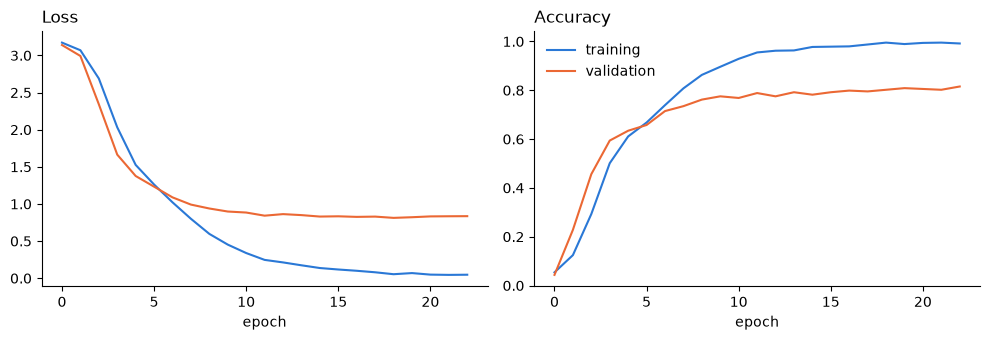

1D-CNN (test)                accuracy 0.827 | macro-F1 0.757 | top-3 0.909


In [10]:
history = cnn.fit(seq(idx_fit), y[idx_fit], validation_data=(seq(idx_val), y[idx_val]), epochs=40, batch_size=32,
                  verbose=0, callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)])
print("Stopped after", len(history.history["loss"]), "epochs")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, k in zip(axes, ["loss", "accuracy"]):
    ax.plot(history.history[k], color="#2a78d6", label="training")
    ax.plot(history.history["val_" + k], color="#eb6834", label="validation")
    ax.set_title(k.title(), loc="left"); ax.set_xlabel("epoch"); ax.spines[["top", "right"]].set_visible(False)
axes[1].legend(frameon=False); plt.tight_layout(); plt.show()
p_cnn_val, p_cnn_test = cnn.predict(seq(idx_val), verbose=0), cnn.predict(seq(idx_test), verbose=0)
report("1D-CNN (test)", y[idx_test], p_cnn_test)

## 7. Ensemble and model selection

Averaging the SVM's and the CNN's probabilities combines two different views of the text: word statistics
and learned phrase patterns. The deployed model is chosen on **validation** macro-F1, so the test set
stays unbiased.

In [11]:
p_ens_val, p_ens_test = (p_svm_val + p_cnn_val) / 2, (p_svm_test + p_cnn_test) / 2
for name, p in [("Linear SVM", p_svm_val), ("1D-CNN", p_cnn_val), ("Ensemble", p_ens_val)]:
    print(f"validation macro-F1  {name:10s} {f1_score(y[idx_val], p.argmax(1), average='macro'):.3f}")
print()
for name, p in [("Linear SVM", p_svm_test), ("1D-CNN", p_cnn_test), ("Ensemble", p_ens_test)]:
    report(name + " (test)", y[idx_test], p)

validation macro-F1  Linear SVM 0.660
validation macro-F1  1D-CNN     0.744
validation macro-F1  Ensemble   0.756

Linear SVM (test)            accuracy 0.757 | macro-F1 0.710 | top-3 0.944
1D-CNN (test)                accuracy 0.827 | macro-F1 0.757 | top-3 0.909
Ensemble (test)              accuracy 0.861 | macro-F1 0.809 | top-3 0.952


## 8. Error analysis

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
pred = p_ens_test.argmax(1)
print(classification_report(y[idx_test], pred, target_names=labels, digits=2, zero_division=0))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.86      1.00      0.92        24
              ADVOCATE       0.79      0.92      0.85        24
           AGRICULTURE       0.89      0.62      0.73        13
               APPAREL       0.80      0.63      0.71        19
                  ARTS       0.81      0.62      0.70        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.95      0.91      0.93        23
               BANKING       0.90      0.78      0.84        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.92      0.96      0.94        24
                  CHEF       1.00      0.83      0.91        24
          CONSTRUCTION       0.91      0.91      0.91        22
            CONSULTANT       0.81      0.91      0.86        23
              DESIGNER       0.91      1.00      0.95        21
         DIGITAL-MEDIA       0.88      

In [13]:
cm = confusion_matrix(y[idx_test], pred, normalize="true")
np.fill_diagonal(cm, 0)
pairs = sorted(((cm[i, j], labels[i], labels[j]) for i in range(len(labels)) for j in range(len(labels)) if cm[i, j] > 0), reverse=True)[:8]
print("Most common confusions (share of the true category):")
for share, true, guess in pairs:
    print(f"  {true:22s} -> {guess:22s} {share:.0%}")

Most common confusions (share of the true category):
  AUTOMOBILE             -> ADVOCATE               43%
  BPO                    -> HR                     25%
  BPO                    -> HEALTHCARE             25%
  BPO                    -> BUSINESS-DEVELOPMENT   25%
  BPO                    -> BANKING                25%
  APPAREL                -> SALES                  21%
  AUTOMOBILE             -> ENGINEERING            14%
  AUTOMOBILE             -> AVIATION               14%


Errors cluster between **overlapping careers**, for example apparel retail staff whose work is mostly
selling, or artists who also teach. The smallest categories suffer most: BPO has only 4 test resumes and
Automobile only 7, so the model sees too few examples of them. The **top-3 accuracy** above shows the right category is almost
always among the model's first three guesses, which is why matching uses the full probability distribution
rather than a single label.

## 9. From classification to candidate matching

The app scores every (resume, job) pair from 0 to 100:

| Signal | Weight | Comes from |
|---|---|---|
| Category fit | 40% | ensemble probability for the job's category |
| Skill match | 30% | share of the job's required skills in the resume |
| Semantic similarity | 20% | cosine similarity of the CNN's 64-number resume vectors |
| Experience fit | 10% | detected years vs. job minimum (ignored if unknown) |

Below, the saved production models (from `train.py`) rank the unseen test resumes for one job.

In [14]:
import json
from jobmatch.models import get_classifier
from jobmatch.matcher import MatchingService
from jobmatch import config

clf = get_classifier()
service = MatchingService(clf)
saved = json.loads(config.METRICS_PATH.read_text())
test_resumes = df.loc[saved["test_rows"]]
job = next(j for j in json.loads(config.JOBS_SEED_FILE.read_text()) if j["category"] == "HR")
print("JOB:", job["title"], "| skills:", ", ".join(job["skills"]), "| min", job["min_experience"], "yrs\n")
cands = [{"text": t, "true": c} for t, c in zip(test_resumes.Resume_str, test_resumes.Category)]
for cand, m in service.rank_candidates(job, cands, limit=8):
    print(f"{m['score']:3d}%  true category {cand['true']:22s} category fit {m['category_fit']:3d}%  "
          f"skills {m['skill_match']:3d}%  semantic {m['semantic_similarity']}%  matched: {', '.join(m['matched_skills'])}")

JOB: HR Generalist | skills: recruiting, onboarding, employee relations, benefits administration, hris, payroll | min 3 yrs



 92%  true category HR                     category fit  92%  skills  83%  semantic 100%  matched: onboarding, employee relations, benefits administration, hris, payroll
 92%  true category HR                     category fit  93%  skills  83%  semantic 100%  matched: recruiting, onboarding, employee relations, hris, payroll
 90%  true category HR                     category fit  88%  skills  83%  semantic 100%  matched: recruiting, onboarding, employee relations, hris, payroll
 87%  true category HR                     category fit  93%  skills  67%  semantic 100%  matched: recruiting, employee relations, hris, payroll
 86%  true category HR                     category fit  91%  skills  67%  semantic 100%  matched: onboarding, employee relations, hris, payroll
 85%  true category HR                     category fit  87%  skills  67%  semantic 100%  matched: recruiting, benefits administration, hris, payroll
 84%  true category HR                     category fit  86%  skills  67%  s

## 10. Matching evaluation

Without human relevance labels, a resume is treated as relevant to a job when it comes from the job's
category. `evaluate_matching.py` ranks all 497 test resumes for each of the 24 jobs and measures how many
of the top 10 are relevant.

In [15]:
mm = json.loads((config.REPORTS_DIR / "matching_metrics.json").read_text())
pd.DataFrame(mm["signals"]).T.rename(columns={"precision_at_10": "Precision@10", "precision_at_20": "Precision@20", "map": "MAP"})

,Precision@10,Precision@20,MAP
Skill keywords only,0.4667,0.3708,0.3491
TF-IDF similarity only (ML),0.5833,0.5125,0.5121
CNN embedding similarity only (DL),0.7125,0.6208,0.6481
Category probability only (ensemble classifier),0.9250,0.8333,0.8759
Final blend (40/30/20/10),0.8708,0.7792,0.8015


The **deep-learning embedding** ranks candidates much better than classical TF-IDF similarity, and the
classifier's category probability is the strongest single signal. The final blend keeps most of that
accuracy while also rewarding concrete skills and experience, which employers can see and verify.

## 11. Conclusion

- A 1D-CNN learns resume categories better than classical ML models on this data, and an ensemble of
  CNN + Linear SVM is best overall.
- Careful evaluation matters: removing duplicates, holding out a test set, and selecting models on
  validation data give honest numbers instead of inflated ones.
- The same models power an explainable job-matching score in the Streamlit app (`streamlit run app.py`).